# Topic 5 — Multiclass Classification: TensorFlow vs sklearn

Dataset: [AeroScan Military Aircraft](https://www.kaggle.com/datasets/ahnuf05/aeroscan-military-aircraft-classification)

**Reduced to the 10 most populated classes** (240 images each in the full set) to validate
whether the bottleneck with all 88 classes was data volume rather than architecture.
Random-chance accuracy here is 10% (vs ~1.1% with 88 classes).

**Progression**: flat MLP (baseline) → CNN → vary kernel size → vary stride → vary padding.

In [73]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print('TF version:', tf.__version__)

TF version: 2.21.0


## 1. Download dataset via kagglehub

In [74]:
import kagglehub

path = kagglehub.dataset_download('ahnuf05/aeroscan-military-aircraft-classification')
print('Dataset path:', path)

TRAIN_DIR = os.path.join(path, 'train')
TEST_DIR  = os.path.join(path, 'test')

Dataset path: /Users/edwinperez/.cache/kagglehub/datasets/ahnuf05/aeroscan-military-aircraft-classification/versions/1


## 2. Load images — top 5 most populated classes only

Labels come from the YOLO `class_id` (first number in each `.txt`).
Original IDs are remapped to 0–4 (contiguous) for the softmax output.

In [90]:
IMG_SIZE      = 48
MAX_PER_CLASS = 150

# Pre-computed: the 5 most populated class_id in the full training set (240 images each)
TOP5_CLASSES = [62, 78, 35, 11, 66]
ID_MAP = {orig: i for i, orig in enumerate(sorted(TOP5_CLASSES))}  # orig_id -> 0..4
N_CLASSES = len(TOP5_CLASSES)

def get_class_id(txt_path):
    with open(txt_path) as f:
        line = f.readline().strip()
    return int(line.split()[0]) if line else None

def load_images_subset(directory, allowed_classes, img_size=IMG_SIZE, max_per_class=MAX_PER_CLASS):
    images, labels = [], []
    counts  = {}
    allowed = set(allowed_classes)
    for fname in sorted(os.listdir(directory)):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        txt_path = os.path.join(directory, os.path.splitext(fname)[0] + '.txt')
        if not os.path.exists(txt_path):
            continue
        cls_id = get_class_id(txt_path)
        if cls_id is None or cls_id not in allowed or counts.get(cls_id, 0) >= max_per_class:
            continue
        img = Image.open(os.path.join(directory, fname)).convert('RGB')
        images.append(np.array(img.resize((img_size, img_size))) / 255.0)
        labels.append(ID_MAP[cls_id])   # remap to 0-4 immediately
        counts[cls_id] = counts.get(cls_id, 0) + 1
    return np.array(images), np.array(labels)

X_train_raw, y_train = load_images_subset(TRAIN_DIR, TOP5_CLASSES)
X_test_raw,  y_test  = load_images_subset(TEST_DIR,  TOP5_CLASSES)
print(f'Train: {X_train_raw.shape}  Test: {X_test_raw.shape}  N classes: {N_CLASSES}')
print(f'Train counts per class: {np.bincount(y_train)}')

Train: (750, 48, 48, 3)  Test: (159, 48, 48, 3)  N classes: 5
Train counts per class: [150 150 150 150 150]


In [91]:
X_train_flat = X_train_raw.reshape(len(X_train_raw), -1)
X_test_flat  = X_test_raw.reshape(len(X_test_raw),  -1)

## 3. Preview sample images

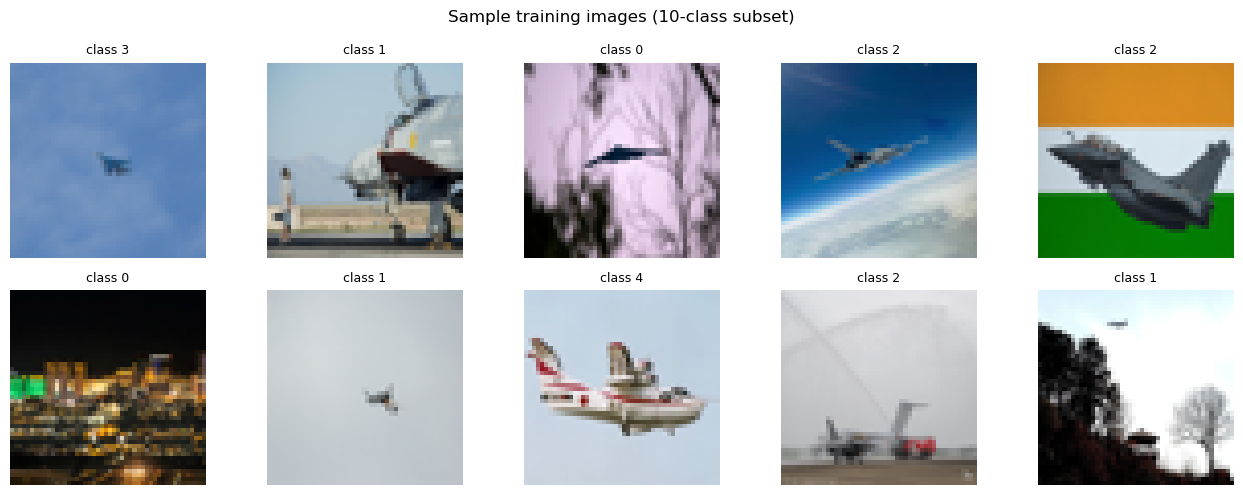

In [92]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5))
idx = np.random.choice(len(X_train_raw), 10, replace=False)
for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train_raw[i])
    ax.set_title(f'class {y_train[i]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Sample training images (10-class subset)', fontsize=12)
plt.tight_layout(); plt.show()

## 4. Helper: train + evaluate any Keras model

Shared training loop so every architecture below is compared fairly.

In [93]:
def train_and_eval(model, name, epochs=40, batch_size=16):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0003),
        loss='sparse_categorical_crossentropy', metrics=['accuracy']
    )
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8, restore_best_weights=True
    )
    hist = model.fit(
        X_train_raw, y_train, validation_data=(X_test_raw, y_test),
        epochs=epochs, batch_size=batch_size, callbacks=[early_stop], verbose=0
    )
    _, acc = model.evaluate(X_test_raw, y_test, verbose=0)
    print(f'{name:30s}  test_acc = {acc:.4f}  (n_params={model.count_params():,})')
    return model, hist, acc

results = {}

## 5. Baseline — flat MLP (no convolutions)

In [94]:
tf.random.set_seed(42)
mlp_model = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(N_CLASSES, activation='softmax'),
], name='Flat_MLP')

results['Flat MLP'] = train_and_eval(mlp_model, 'Flat MLP')

Flat MLP                        test_acc = 0.2138  (n_params=1,803,269)


## 6. CNN baseline

Two Conv2D blocks (kernel=3, stride=1, padding='same') + pooling, then dense head.

In [95]:
def make_cnn(kernel_size=3, strides=1, padding='same', name='CNN'):
    return keras.Sequential([
        keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        keras.layers.Conv2D(32, kernel_size, strides=strides, padding=padding, activation='relu'),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(64, kernel_size, strides=strides, padding=padding, activation='relu'),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(N_CLASSES, activation='softmax'),
    ], name=name)

tf.random.set_seed(42)
cnn_base = make_cnn(kernel_size=3, strides=1, padding='same', name='CNN_baseline')
results['CNN baseline (k=3,s=1,same)'] = train_and_eval(cnn_base, 'CNN baseline (k=3,s=1,same)')

CNN baseline (k=3,s=1,same)     test_acc = 0.3522  (n_params=1,199,813)


## 7. Varying kernel size

Stride and padding fixed at baseline (1, 'same').

In [96]:
for k in [3, 5, 7]:
    tf.random.set_seed(42)
    model = make_cnn(kernel_size=k, strides=1, padding='same', name=f'CNN_k{k}')
    results[f'kernel_size={k}'] = train_and_eval(model, f'kernel_size={k}')

kernel_size=3                   test_acc = 0.3585  (n_params=1,199,813)
kernel_size=5                   test_acc = 0.3585  (n_params=1,234,117)
kernel_size=7                   test_acc = 0.3145  (n_params=1,285,573)


## 8. Varying stride

Kernel fixed at 3, padding fixed at 'same'.

In [97]:
for s in [1, 2, 3]:
    tf.random.set_seed(42)
    model = make_cnn(kernel_size=3, strides=s, padding='same', name=f'CNN_s{s}')
    results[f'stride={s}'] = train_and_eval(model, f'stride={s}')

stride=1                        test_acc = 0.3648  (n_params=1,199,813)
stride=2                        test_acc = 0.2516  (n_params=93,893)
stride=3                        test_acc = 0.2956  (n_params=28,357)


## 9. Varying padding

Kernel and stride fixed at baseline (3, 1).

In [98]:
for p in ['same', 'valid']:
    tf.random.set_seed(42)
    model = make_cnn(kernel_size=3, strides=1, padding=p, name=f'CNN_{p}')
    results[f'padding={p}'] = train_and_eval(model, f'padding={p}')

padding=same                    test_acc = 0.3774  (n_params=1,199,813)
padding=valid                   test_acc = 0.3145  (n_params=839,365)


## 10. Comparison summary

Experiment                       Test acc      Params
-----------------------------------------------------
(random chance baseline: 0.2000)
Flat MLP                           0.2138   1,803,269
CNN baseline (k=3,s=1,same)        0.3522   1,199,813
kernel_size=3                      0.3585   1,199,813
kernel_size=5                      0.3585   1,234,117
kernel_size=7                      0.3145   1,285,573
stride=1                           0.3648   1,199,813
stride=2                           0.2516      93,893
stride=3                           0.2956      28,357
padding=same                       0.3774   1,199,813
padding=valid                      0.3145     839,365


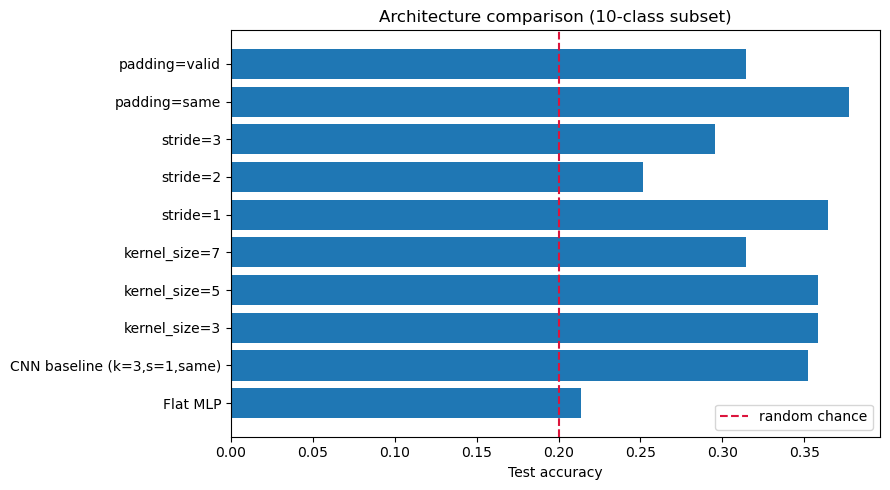

In [99]:
print(f'{"Experiment":30s}  {"Test acc":>9}  {"Params":>10}')
print('-' * 53)
print(f'(random chance baseline: {1/N_CLASSES:.4f})')
for name, (model, hist, acc) in results.items():
    print(f'{name:30s}  {acc:>9.4f}  {model.count_params():>10,}')

fig, ax = plt.subplots(figsize=(9, 5))
names = list(results.keys())
accs  = [results[n][2] for n in names]
ax.barh(names, accs, color='C0')
ax.axvline(1/N_CLASSES, color='crimson', ls='--', label='random chance')
ax.set_xlabel('Test accuracy'); ax.set_title('Architecture comparison (10-class subset)')
ax.legend()
plt.tight_layout(); plt.show()

## 11. Best model — sklearn MLP comparison

In [100]:
mlp_sk = MLPClassifier(
    hidden_layer_sizes=(256, 128), activation='relu', solver='adam',
    max_iter=40, random_state=42
)
mlp_sk.fit(X_train_flat, y_train)
sk_acc = mlp_sk.score(X_test_flat, y_test)

best_name = max(results, key=lambda n: results[n][2])
print(f'sklearn MLP (flat):            test_acc = {sk_acc:.4f}')
print(f'TF Flat MLP:                   test_acc = {results["Flat MLP"][2]:.4f}')
print(f'Best CNN config ({best_name}): test_acc = {results[best_name][2]:.4f}')

sklearn MLP (flat):            test_acc = 0.2390
TF Flat MLP:                   test_acc = 0.2138
Best CNN config (padding=same): test_acc = 0.3774


/Users/edwinperez/miniconda3/envs/advanced_lab_NN_packs/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (40) reached and the optimization hasn't converged yet.
  warnings.warn(


## 12. Confusion matrix and report — best model

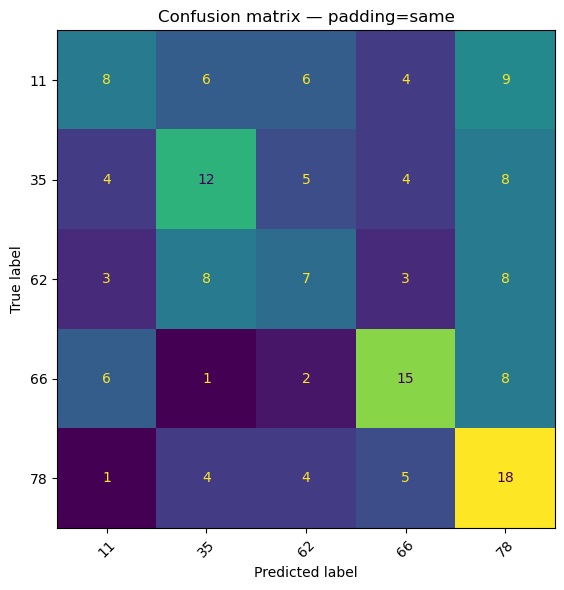

              precision    recall  f1-score   support

          11       0.36      0.24      0.29        33
          35       0.39      0.36      0.38        33
          62       0.29      0.24      0.26        29
          66       0.48      0.47      0.48        32
          78       0.35      0.56      0.43        32

    accuracy                           0.38       159
   macro avg       0.38      0.38      0.37       159
weighted avg       0.38      0.38      0.37       159



In [102]:
best_model = results[best_name][0]
y_pred = np.argmax(best_model.predict(X_test_raw, verbose=0), axis=1)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=[str(c) for c in sorted(TOP5_CLASSES)],
    xticks_rotation=45, ax=ax, colorbar=False
)
ax.set_title(f'Confusion matrix — {best_name}', fontsize=12)
plt.tight_layout(); plt.show()

print(classification_report(
    y_test, y_pred,
    target_names=[str(c) for c in sorted(TOP5_CLASSES)],
    zero_division=0
))

## 13. Inspect predictions on random test images

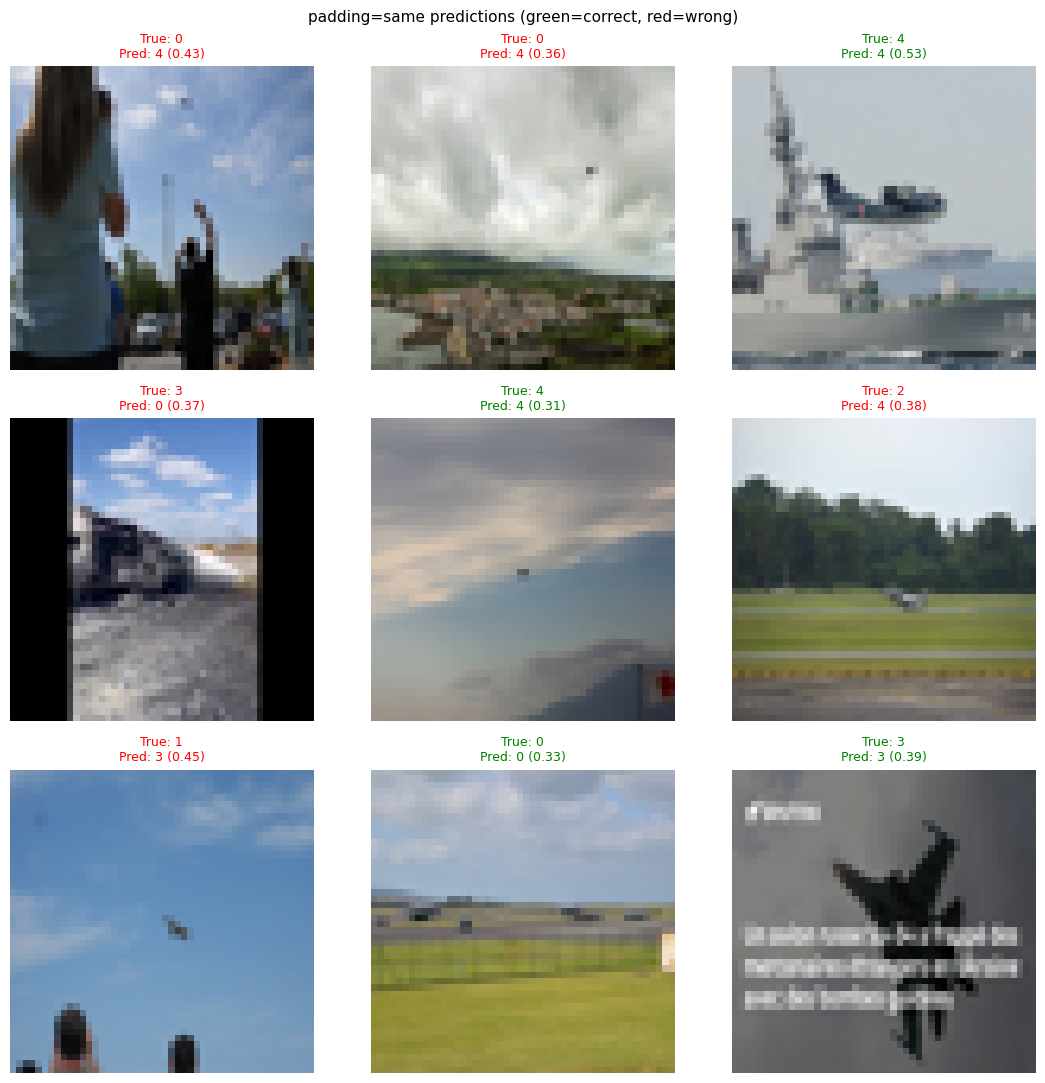

In [103]:
idx   = np.random.choice(len(X_test_raw), 9, replace=False)
probs = best_model.predict(X_test_raw[idx], verbose=0)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax, i, prob in zip(axes.flat, idx, probs):
    pred  = np.argmax(prob)
    conf  = prob[pred]
    color = 'green' if pred == y_test[i] else 'red'
    ax.imshow(X_test_raw[i])
    ax.set_title(f'True: {y_test[i]}\nPred: {pred} ({conf:.2f})', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle(f'{best_name} predictions (green=correct, red=wrong)', fontsize=11)
plt.tight_layout(); plt.show()

## 14. Prueba del Efecto de Resolución de Imagen

In [ ]:
# Aislar el efecto de la resolución, manteniendo las mismas 10 clases
for size in [48, 64, 96]:
    X_tr, y_tr = load_images_subset(TRAIN_DIR, TOP10_CLASSES, img_size=size)
    X_te, y_te = load_images_subset(TEST_DIR,  TOP10_CLASSES, img_size=size)

    tf.random.set_seed(42)
    model = keras.Sequential([
        keras.layers.Input(shape=(size, size, 3)),
        keras.layers.Conv2D(32, 3, padding='valid', activation='relu'),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(64, 3, padding='valid', activation='relu'),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(N_CLASSES, activation='softmax'),
    ], name=f'CNN_size{size}')

    model.compile(optimizer=keras.optimizers.Adam(0.0003),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    early_stop = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
                                               restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
             epochs=40, batch_size=16, callbacks=[early_stop], verbose=0)

    _, acc = model.evaluate(X_te, y_te, verbose=0)
    print(f'img_size={size:3d}  test_acc={acc:.4f}  (n_train={len(X_tr)})')

img_size= 48  test_acc=0.2077  (n_train=1500)
img_size= 64  test_acc=0.1917  (n_train=1500)
img_size= 96  test_acc=0.1789  (n_train=1500)
